# Lock two spline shapes, estimate their scales, and fit another spline

This notebook demonstrates a Binomial/Logit model of the form

$$
\operatorname{logit}(p_i) = \alpha + \beta_1 f_1(x_{1i}) + \beta_2 f_2(x_{2i}) + g(x_{3i}),
\qquad \beta_1, \beta_2 \ge 0.
$$

- `f1` and `f2` are fixed PCHIP shapes built from hand-drawn control points.
- Their shapes never change; the model estimates only the non-negative scales `beta_1` and `beta_2`.
- `g` is a free cubic B-spline fitted with a second-difference roughness penalty.
- Because the scales are estimated, the locked effects are **not offsets**. An offset would fix each coefficient at exactly 1.

The example uses synthetic data with known truth so recovery can be checked directly.

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import BSpline, PchipInterpolator
from scipy.optimize import OptimizeResult, minimize
from scipy.special import expit

SEED = 20260717
N_OBSERVATIONS = 20_000
SPLINE_DEGREE = 3
N_INTERNAL_KNOTS = 8

rng = np.random.default_rng(SEED)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Model helpers

The locked curves are evaluated once and then treated as fixed columns. Each curve is centered before fitting so the intercept controls the baseline level rather than compensating for an arbitrary vertical shift.

For a candidate smoothing penalty $\lambda$, the fitted parameters minimize

$$
\frac{1}{n}\sum_i\left[\log(1 + e^{\eta_i}) - y_i\eta_i\right]
+ \frac{\lambda}{2}\lVert D_2\gamma\rVert_2^2,
$$

where $\gamma$ contains the free B-spline coefficients and $D_2$ is a second-difference matrix. Bounds on the optimizer enforce $\beta_1,\beta_2\ge0$.

In [7]:
def make_knot_vector(
    lower: float,
    upper: float,
    n_internal: int = N_INTERNAL_KNOTS,
    degree: int = SPLINE_DEGREE,
) -> np.ndarray:
    internal = np.linspace(lower, upper, n_internal + 2)[1:-1]
    return np.concatenate(
        (np.repeat(lower, degree + 1), internal, np.repeat(upper, degree + 1))
    )


def bspline_design(
    x: np.ndarray,
    knots: np.ndarray,
    degree: int = SPLINE_DEGREE,
) -> np.ndarray:
    n_basis = len(knots) - degree - 1
    coefficients = np.eye(n_basis)
    return BSpline(knots, coefficients, degree, extrapolate=False)(x)


def binomial_log_loss(y: np.ndarray, eta: np.ndarray) -> float:
    return float(np.mean(np.logaddexp(0.0, eta) - y * eta))


def fit_locked_shape_logit(
    y: np.ndarray,
    locked_effects: np.ndarray,
    free_basis: np.ndarray,
    smoothing_penalty: float,
) -> OptimizeResult:
    n_observations = len(y)
    n_basis = free_basis.shape[1]
    second_difference = np.diff(np.eye(n_basis), n=2, axis=0)
    penalty_matrix = second_difference.T @ second_difference

    def objective(parameters: np.ndarray) -> tuple[float, np.ndarray]:
        intercept = parameters[0]
        locked_scales = parameters[1:3]
        spline_coefficients = parameters[3:]
        eta = (
            intercept
            + locked_effects @ locked_scales
            + free_basis @ spline_coefficients
        )
        residual = expit(eta) - y

        loss = binomial_log_loss(y, eta)
        loss += 0.5 * smoothing_penalty * (
            spline_coefficients @ penalty_matrix @ spline_coefficients
        )
        loss += 0.5e-10 * (spline_coefficients @ spline_coefficients)

        gradient = np.concatenate(
            (
                [np.mean(residual)],
                locked_effects.T @ residual / n_observations,
                free_basis.T @ residual / n_observations
                + smoothing_penalty * (penalty_matrix @ spline_coefficients)
                + 1e-10 * spline_coefficients,
            )
        )
        return loss, gradient

    prevalence = np.clip(np.mean(y), 1e-6, 1.0 - 1e-6)
    initial = np.zeros(3 + n_basis)
    initial[0] = np.log(prevalence / (1.0 - prevalence))
    bounds = [(None, None), (0.0, None), (0.0, None)] + [
        (None, None)
    ] * n_basis

    return minimize(
        objective,
        initial,
        jac=True,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 2_000, "ftol": 1e-12, "gtol": 1e-8},
    )

## 2. Create two hand-drawn locked shapes and synthetic outcomes

The PCHIP interpolators turn control points into smooth curves without the overshoot that an unconstrained cubic spline can introduce. Their centers are computed on a dense reference grid and then held fixed for every dataset split.

The outcome is generated with known positive scales and a separate nonlinear effect of `x3`. The fitting step sees the evaluated locked curves, not their control points.

In [8]:
CONTROL_X = np.array([0.0, 0.15, 0.35, 0.55, 0.75, 1.0])
CONTROL_Y_1 = np.array([-0.8, -0.55, -0.1, 0.55, 0.9, 1.05])
CONTROL_Y_2 = np.array([0.7, 0.2, -0.45, -0.75, -0.25, 0.55])

locked_curve_1 = PchipInterpolator(CONTROL_X, CONTROL_Y_1)
locked_curve_2 = PchipInterpolator(CONTROL_X, CONTROL_Y_2)
reference_grid = np.linspace(0.0, 1.0, 20_001)
locked_shape_fingerprint = np.column_stack(
    (locked_curve_1(reference_grid), locked_curve_2(reference_grid))
).copy()
locked_center_1 = float(np.mean(locked_curve_1(reference_grid)))
locked_center_2 = float(np.mean(locked_curve_2(reference_grid)))

x1 = rng.uniform(0.0, 1.0, N_OBSERVATIONS)
x2 = rng.uniform(0.0, 1.0, N_OBSERVATIONS)
x3 = rng.uniform(-1.0, 1.0, N_OBSERVATIONS)
locked_effect_1 = locked_curve_1(x1) - locked_center_1
locked_effect_2 = locked_curve_2(x2) - locked_center_2
locked_effects = np.column_stack((locked_effect_1, locked_effect_2))


def true_free_effect(x: np.ndarray) -> np.ndarray:
    return 0.95 * np.sin(1.35 * np.pi * x) + 0.25 * x


TRUE_INTERCEPT = -1.1
TRUE_LOCKED_SCALES = np.array([1.4, 0.9])
true_eta = (
    TRUE_INTERCEPT
    + locked_effects @ TRUE_LOCKED_SCALES
    + true_free_effect(x3)
)
outcome = rng.binomial(1, expit(true_eta))

print(f"Observations: {N_OBSERVATIONS:,}")
print(f"Event rate: {outcome.mean():.2%}")

Observations: 20,000
Event rate: 30.20%


## 3. Select the free-spline penalty and refit

The data are split into training, validation, and test samples. Only the roughness penalty for `g(x3)` is selected on validation log-loss. The two locked-curve scales are unpenalized but bounded below by zero.

After selecting $\lambda$, the model is refitted on training plus validation data and evaluated once on the untouched test sample.

In [9]:
permuted_indices = rng.permutation(N_OBSERVATIONS)
train_indices = permuted_indices[:12_000]
validation_indices = permuted_indices[12_000:16_000]
test_indices = permuted_indices[16_000:]

knots = make_knot_vector(-1.0, 1.0)
raw_basis = bspline_design(x3, knots)
train_basis_mean = raw_basis[train_indices].mean(axis=0)
train_basis = raw_basis[train_indices] - train_basis_mean
validation_basis = raw_basis[validation_indices] - train_basis_mean

validation_rows = []
for smoothing_penalty in np.logspace(-5, -1, 9):
    candidate = fit_locked_shape_logit(
        outcome[train_indices],
        locked_effects[train_indices],
        train_basis,
        smoothing_penalty,
    )
    validation_eta = (
        candidate.x[0]
        + locked_effects[validation_indices] @ candidate.x[1:3]
        + validation_basis @ candidate.x[3:]
    )
    validation_rows.append(
        {
            "lambda": smoothing_penalty,
            "validation_log_loss": binomial_log_loss(
                outcome[validation_indices], validation_eta
            ),
            "optimizer_success": candidate.success,
        }
    )

validation_results = pd.DataFrame(validation_rows)
best_penalty = float(
    validation_results.loc[
        validation_results["validation_log_loss"].idxmin(), "lambda"
    ]
)

fit_indices = np.concatenate((train_indices, validation_indices))
fit_basis_mean = raw_basis[fit_indices].mean(axis=0)
fit_basis = raw_basis[fit_indices] - fit_basis_mean
test_basis = raw_basis[test_indices] - fit_basis_mean
fitted_model = fit_locked_shape_logit(
    outcome[fit_indices],
    locked_effects[fit_indices],
    fit_basis,
    best_penalty,
)

test_eta = (
    fitted_model.x[0]
    + locked_effects[test_indices] @ fitted_model.x[1:3]
    + test_basis @ fitted_model.x[3:]
)
test_probability = expit(test_eta)

validation_results.style.format(
    {"lambda": "{:.5g}", "validation_log_loss": "{:.6f}"}
).highlight_min(subset=["validation_log_loss"], color="#d8f3dc")

,lambda,validation_log_loss,optimizer_success
0,1e-05,0.514180,True
1,3.1623e-05,0.513989,True
2,0.0001,0.513746,True
3,0.00031623,0.513509,True
4,0.001,0.513293,True
5,0.0031623,0.513306,True
6,0.01,0.514214,True
7,0.031623,0.517982,True
8,0.1,0.526646,True


In [10]:
estimated_scales = fitted_model.x[1:3]
model_test_log_loss = binomial_log_loss(outcome[test_indices], test_eta)
baseline_probability = np.clip(outcome[fit_indices].mean(), 1e-6, 1.0 - 1e-6)
baseline_eta = np.full(
    len(test_indices),
    np.log(baseline_probability / (1.0 - baseline_probability)),
)
baseline_test_log_loss = binomial_log_loss(outcome[test_indices], baseline_eta)

x3_grid = np.linspace(-1.0, 1.0, 501)
grid_basis = bspline_design(x3_grid, knots) - fit_basis_mean
estimated_free_effect = grid_basis @ fitted_model.x[3:]
true_free_effect_grid = true_free_effect(x3_grid)
estimated_free_effect -= np.mean(estimated_free_effect)
true_free_effect_grid -= np.mean(true_free_effect_grid)
free_spline_rmse = float(
    np.sqrt(np.mean((estimated_free_effect - true_free_effect_grid) ** 2))
)

scale_summary = pd.DataFrame(
    {
        "locked_shape": ["f1(x1)", "f2(x2)"],
        "true_beta": TRUE_LOCKED_SCALES,
        "estimated_beta": estimated_scales,
        "absolute_error": np.abs(estimated_scales - TRUE_LOCKED_SCALES),
    }
)
metric_summary = pd.Series(
    {
        "selected_lambda": best_penalty,
        "test_log_loss": model_test_log_loss,
        "intercept_only_log_loss": baseline_test_log_loss,
        "free_spline_link_scale_rmse": free_spline_rmse,
    },
    name="value",
)

print(scale_summary.to_string(index=False, float_format=lambda value: f"{value:.4f}"))
print()
print(metric_summary.to_string(float_format=lambda value: f"{value:.6f}"))

current_locked_shapes = np.column_stack(
    (locked_curve_1(reference_grid), locked_curve_2(reference_grid))
)
assert validation_results["optimizer_success"].all()
assert fitted_model.success
assert np.all(estimated_scales >= 0.0)
assert np.max(np.abs(estimated_scales - TRUE_LOCKED_SCALES)) < 0.15
assert free_spline_rmse < 0.15
assert model_test_log_loss < baseline_test_log_loss - 0.05
assert np.array_equal(current_locked_shapes, locked_shape_fingerprint)
print("\nAll numerical checks passed.")

locked_shape  true_beta  estimated_beta  absolute_error
      f1(x1)     1.4000          1.4695          0.0695
      f2(x2)     0.9000          0.9402          0.0402

selected_lambda               0.001000
test_log_loss                 0.509479
intercept_only_log_loss       0.614442
free_spline_link_scale_rmse   0.074590

All numerical checks passed.


## 4. Visual checks

For each locked feature, the fitted contribution must be a positive scalar multiple of the original centered shape. Only the vertical scale may differ. The third panel checks whether the separately fitted spline recovers the unknown nonlinear effect. The final panel checks out-of-sample probability calibration.

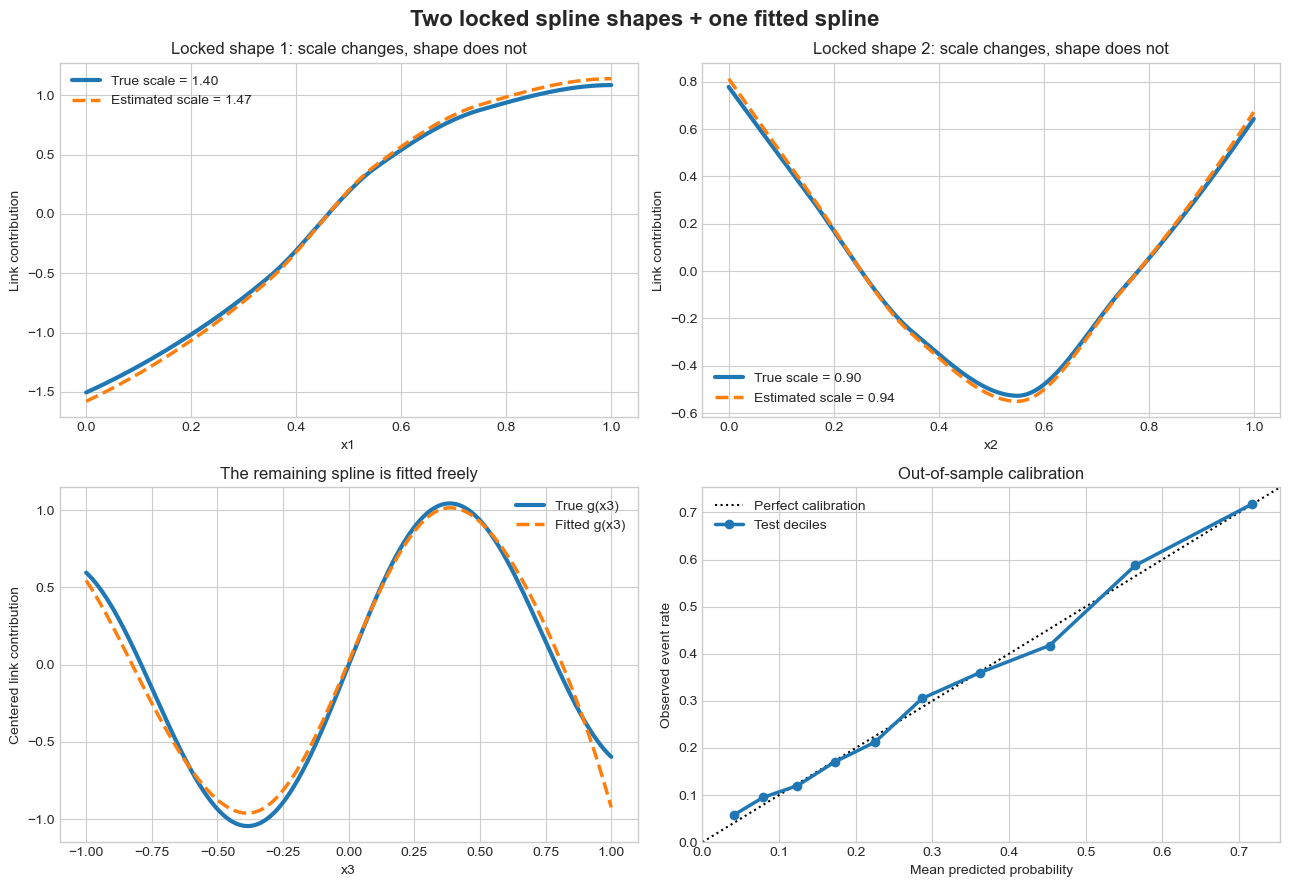

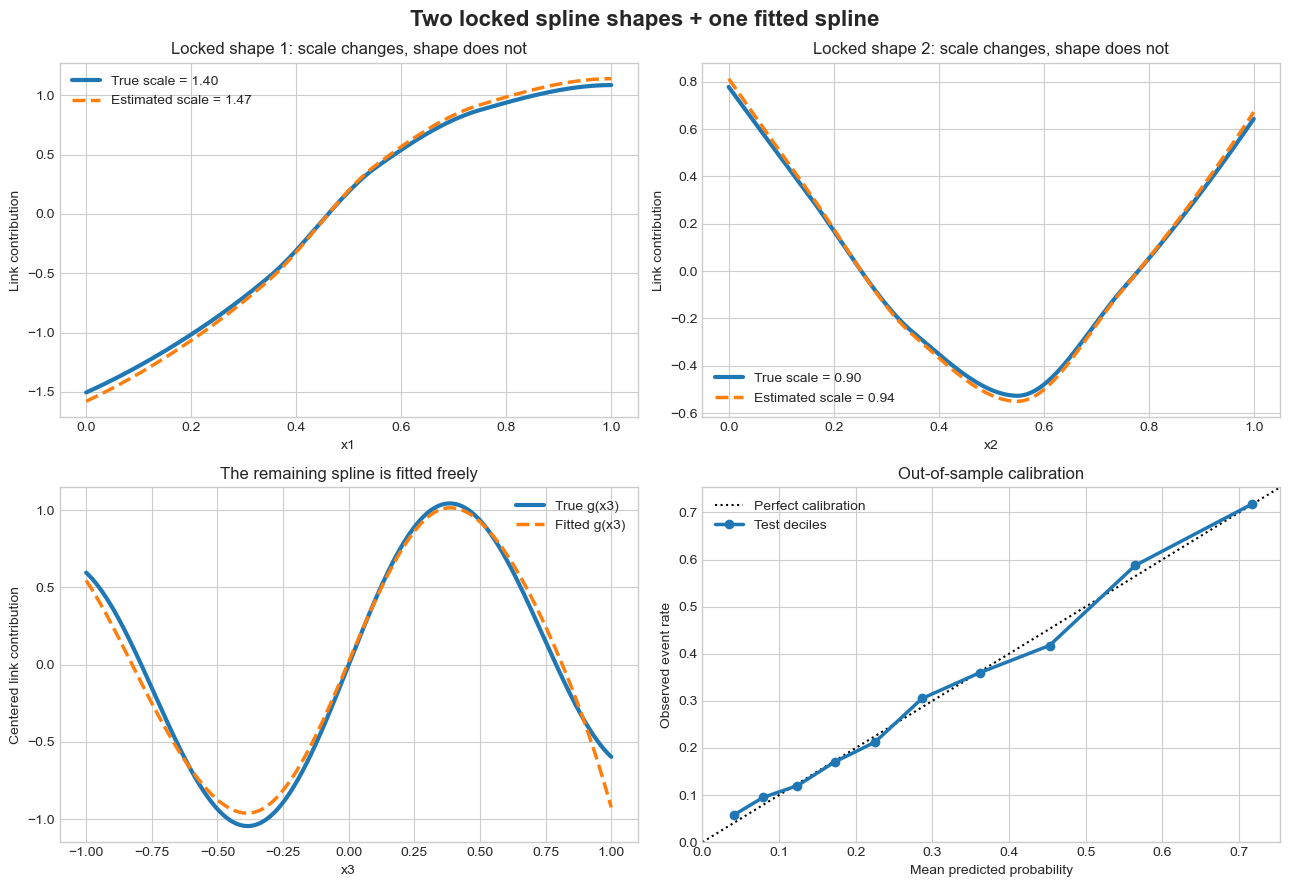

In [11]:
locked_grid = np.linspace(0.0, 1.0, 501)
locked_shape_1_grid = locked_curve_1(locked_grid) - locked_center_1
locked_shape_2_grid = locked_curve_2(locked_grid) - locked_center_2

calibration_edges = np.quantile(test_probability, np.linspace(0.0, 1.0, 11))
calibration_bin = np.digitize(test_probability, calibration_edges[1:-1])
calibration_predicted = np.array(
    [test_probability[calibration_bin == index].mean() for index in range(10)]
)
calibration_observed = np.array(
    [outcome[test_indices][calibration_bin == index].mean() for index in range(10)]
)

figure, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(
    locked_grid,
    TRUE_LOCKED_SCALES[0] * locked_shape_1_grid,
    linewidth=3,
    label=f"True scale = {TRUE_LOCKED_SCALES[0]:.2f}",
)
axes[0, 0].plot(
    locked_grid,
    estimated_scales[0] * locked_shape_1_grid,
    "--",
    linewidth=2.5,
    label=f"Estimated scale = {estimated_scales[0]:.2f}",
)
axes[0, 0].set(title="Locked shape 1: scale changes, shape does not", xlabel="x1", ylabel="Link contribution")
axes[0, 0].legend()

axes[0, 1].plot(
    locked_grid,
    TRUE_LOCKED_SCALES[1] * locked_shape_2_grid,
    linewidth=3,
    label=f"True scale = {TRUE_LOCKED_SCALES[1]:.2f}",
)
axes[0, 1].plot(
    locked_grid,
    estimated_scales[1] * locked_shape_2_grid,
    "--",
    linewidth=2.5,
    label=f"Estimated scale = {estimated_scales[1]:.2f}",
)
axes[0, 1].set(title="Locked shape 2: scale changes, shape does not", xlabel="x2", ylabel="Link contribution")
axes[0, 1].legend()

axes[1, 0].plot(x3_grid, true_free_effect_grid, linewidth=3, label="True g(x3)")
axes[1, 0].plot(x3_grid, estimated_free_effect, "--", linewidth=2.5, label="Fitted g(x3)")
axes[1, 0].set(title="The remaining spline is fitted freely", xlabel="x3", ylabel="Centered link contribution")
axes[1, 0].legend()

calibration_limit = max(calibration_predicted.max(), calibration_observed.max()) * 1.05
axes[1, 1].plot([0.0, calibration_limit], [0.0, calibration_limit], color="black", linestyle=":", label="Perfect calibration")
axes[1, 1].plot(calibration_predicted, calibration_observed, marker="o", linewidth=2.5, label="Test deciles")
axes[1, 1].set(
    title="Out-of-sample calibration",
    xlabel="Mean predicted probability",
    ylabel="Observed event rate",
    xlim=(0.0, calibration_limit),
    ylim=(0.0, calibration_limit),
)
axes[1, 1].legend()

figure.suptitle("Two locked spline shapes + one fitted spline", fontsize=16, fontweight="bold")
figure.tight_layout()
figure

## Conclusion

This case does require an optimizer, but not because the curves are splines. Optimization is required because the model must estimate `beta_1`, `beta_2`, and the free-spline coefficients jointly under `beta >= 0` constraints.

- **Fix shape and amplitude:** use the curve contribution as an `offset`; its coefficient is exactly 1.
- **Fix shape but estimate a positive scale:** use the curve contribution as a fixed model column and constrain its coefficient, as above.
- **Fit the curve itself:** include its spline basis among the parameters; then the shape is no longer locked.

For real data, replace the synthetic outcome and inputs while preserving the same sequence: evaluate locked curves on the link scale, apply the same saved centering constants used when the locked curves were defined, construct the free-feature basis, and fit all remaining parameters jointly.